# Problem Set 4: Kernel Density Estimation
## Fiona St.Clair

**AI Disclosure:** I used Claude by Anthropic to help me work through and write up these problems. I mainly adapted the Python code from the class slides on kernel density estimation but used Claude to check my work and help when I got stuck. The reasoning and written responses are my own.
***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

## Helper functions (adapted from the class slides)

In [22]:
# Uniform kernel KDE at a single point x (from the slides: count points within h, divide by 2nh)
def kde_u_point(X,x,h):
    X = np.array(X)
    n = len(X)
    return np.sum(np.abs(X-x)<h)/(2*n*h)

# Gaussian kernel KDE at a single point x (from the slides)
gauss = lambda z: np.exp(-z**2/2)/np.sqrt(2*np.pi)

def kde_g_point(X,x,h):
    X = np.array(X)
    return np.mean(gauss((X-x)/h)/h)

# Uniform KDE plot over a grid (same idea as the kde() function in the slides)
def kde_u_plot(X,h,K=400,title=''):
    X = np.array(X)
    n = len(X)
    x_grid = np.linspace(X.min()-2*h, X.max()+2*h, K)
    I = np.abs(x_grid[:, None]-X[None, :]) < h
    f_hat = np.sum(I, axis=1)/(2*n*h)
    plt.step(x_grid, f_hat, where='mid')
    plt.fill_between(x_grid, f_hat, step='mid', alpha=0.4)
    plt.title(title)
    plt.show()
    return x_grid, f_hat

***
## Problem 1

In [3]:
X1 = np.array([1, 1.75, 2, 3, 3.25, 4])
n1 = len(X1)

### 1a. Empirical CDF

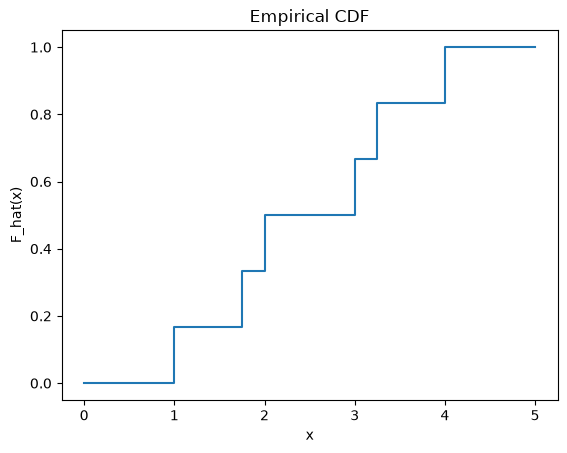

In [23]:
x_sorted = np.sort(X1)
F_hat = np.arange(1, n1 + 1) / n1

plt.step(np.concatenate([[0], x_sorted, [5]]),
         np.concatenate([[0], F_hat, [1]]), where='post')
plt.title('Empirical CDF')
plt.xlabel('x')
plt.ylabel('F_hat(x)')
plt.show()

### 1b. Uniform KDE with h = 0.2

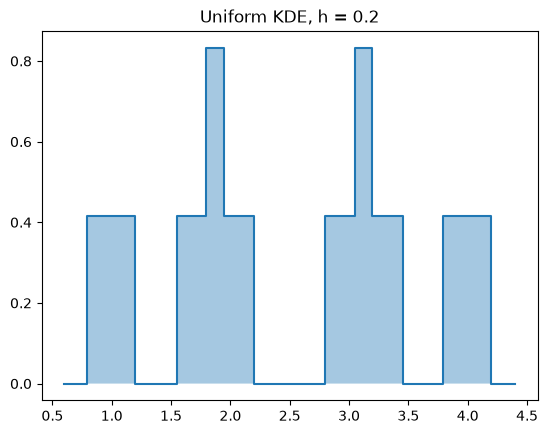

In [5]:
kde_u_plot(X1, h=0.2, title='Uniform KDE, h = 0.2');

### 1c. Silverman bandwidth for the uniform kernel
h = 1.84 * SD * n(^-0.2) w/ `X.std()` like slides

In [6]:
h_silver = 1.84 * X1.std() * n1 ** (-0.2)
print(f'SD = {X1.std():.4f}')
print(f'Silverman bandwidth h = {h_silver:.4f}')

SD = 1.0104
Silverman bandwidth h = 1.2992


### 1d. Uniform KDE with the Silverman bandwidth

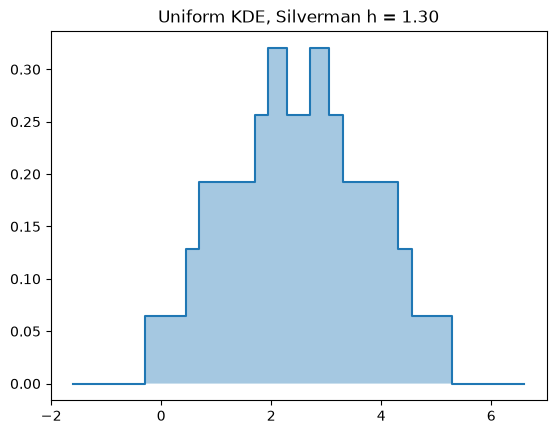

In [7]:
kde_u_plot(X1, h=h_silver, title=f'Uniform KDE, Silverman h = {h_silver:.2f}');

### 1e. Comparing b and d

They are similar because both are blocky uniform KDEs and have a total area under the line of 1. They differ because, with the bandwidth set at .2, the windows are so small that each data point gets its own box with gaps of 0 in between them. With the Silverman's bandwidth of 1.3, each window covers more points, so the blocks overlap into one wide spread over roughly 0 to 5. It shows the overall shape of the distribution better, but smooths away detail.

***
## Problem 2

In [8]:
X2 = np.array([-1, -0.5, 0, 0.5, 1])
n2 = len(X2)

### 2a. Realized uniform KDE at x = 0 with h = 0.6

The bandwidth is 0.6, so the window around x = 0 goes from -0.6 to 0.6. Three of the five data points fall inside that window: -0.5, 0, and 0.5. The points -1 and 1 are too far away.
To get the density estimate, divide the count by (2 × number of data points × bandwidth):

3 ÷ (2 × 5 × 0.6) = 3 ÷ 6 = 0.5

In [9]:
h = 0.6
print('points inside window:', np.sum(np.abs(X2 - 0) < h))
print('f_hat(0) =', kde_u_point(X2, 0, h))

points inside window: 3
f_hat(0) = 0.5


### 2b. Expected value of the KDE at x = 0, h = 0.6

0.4515 / 1.2 = 0.376

In [10]:
def expected_kde_u(x, h):
    return (norm.cdf(x + h) - norm.cdf(x - h)) / (2 * h)

E_06 = expected_kde_u(0, 0.6)
print(f'E[f_hat(0)] with h = 0.6: {E_06:.4f}')

E[f_hat(0)] with h = 0.6: 0.3762


### 2c. True Normal density at x = 0
1 ÷ sqrt(2 * 3.1416) = 1 / 2.5066 = 0.399

In [11]:
f0 = norm.pdf(0)   # same as 1/np.sqrt(2*np.pi)
print(f'true f(0) = {f0:.4f}')

true f(0) = 0.3989


### 2d. Are b and c equal?

In [12]:
print(f'Bias at x=0 (h=0.6): {E_06 - f0:.4f}')

Bias at x=0 (h=0.6): -0.0227


No. E[f hat (0)] = 0.376 is less than the true f(0) = 0.399. Since the expected value of the estimator is not equal to the true value, the KDE is biased. At the peak it is biased downward, because averaging over a window of width 2h mixes in lower-density values near the edges and flattens the peak.

### 2e. Smaller bandwidth, h = 0.1

In [13]:
E_01 = expected_kde_u(0, 0.1)
print(f'E[f_hat(0)] with h = 0.1: {E_01:.4f}')
print(f'gap with h = 0.6: {f0 - E_06:.4f}')
print(f'gap with h = 0.1: {f0 - E_01:.4f}')

E[f_hat(0)] with h = 0.1: 0.3983
gap with h = 0.6: 0.0227
gap with h = 0.1: 0.0007


The gap between E[f hat(0)] and f(0) gets much smaller as h shrinks. As h goes to 0, the expected value approaches the true density, so the bias goes to 0.

### 2f. Is f hat_h consistent?
Yes, as long as the bandwidth shrinks as n grows but not too fast b/c we need n·h to go to infinity.

As h goes to 0, the bias also goes to 0. As n grows, more points land in each window, so the variance shrinks. With both going to 0, f hat gets closer to the true f as the sample gets large. So the KDE is biased but consistent.

### 2g. Choosing h
- Bias–variance tradeoff: Small h = less bias but noisy/spiky/high variance. Large h = smooth but biased, can hide real features like peaks or two modes.
- Sample size: More data lets you use a smaller h.
- Spread of the data: h should scale with the SD.
- Kernel choice: rule of thumb constant depends on the kernel (1.84 for uniform, 1.06 for Gaussian).

***
## Problem 3
Data: `X = [5, 7, 7, 8, 10]`, h = 1.5 for both kernels.

In [14]:
X3 = np.array([5, 7, 7, 8, 10])
h3 = 1.5
x_points = [6.0, 6.5, 7.0, 8.0, 8.5]

### 3a. Uniform KDE
Denominator = 2 · 5 · 1.5 = 15. Note: a point exactly 1.5 away is **not** counted since the slides use a strict `<`.

In [15]:
uniform_vals = [kde_u_point(X3, x, h3) for x in x_points]
for x, f in zip(x_points, uniform_vals):
    inside = X3[np.abs(X3 - x) < h3]
    print(f'x = {x}: points inside = {inside.tolist()}, f_hat = {f:.4f}')

x = 6.0: points inside = [5, 7, 7], f_hat = 0.2000
x = 6.5: points inside = [7, 7], f_hat = 0.1333
x = 7.0: points inside = [7, 7, 8], f_hat = 0.2000
x = 8.0: points inside = [7, 7, 8], f_hat = 0.2000
x = 8.5: points inside = [8], f_hat = 0.0667


### 3b. Gaussian KDE

In [16]:
gauss_vals = [kde_g_point(X3, x, h3) for x in x_points]
for x, f in zip(x_points, gauss_vals):
    print(f'x = {x}: f_hat = {f:.4f}')

x = 6.0: f_hat = 0.1512
x = 6.5: f_hat = 0.1687
x = 7.0: f_hat = 0.1780
x = 8.0: f_hat = 0.1674
x = 8.5: f_hat = 0.1506


In [17]:
pd.DataFrame({'x': x_points, 'uniform': np.round(uniform_vals, 4), 'gaussian': np.round(gauss_vals, 4)})

,x,uniform,gaussian
0,6.0,0.2000,0.1512
1,6.5,0.1333,0.1687
2,7.0,0.2000,0.1780
3,8.0,0.2000,0.1674
4,8.5,0.0667,0.1506


### 3c. Where is the biggest jump?

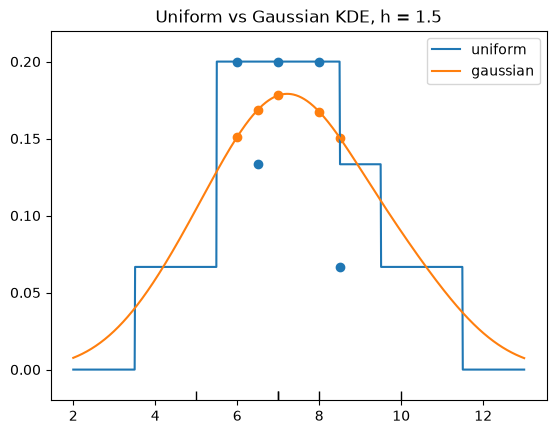

In [18]:
# plot both over a fine grid to see the jumps
grid = np.linspace(2, 13, 1000)
plt.plot(grid, [kde_u_point(X3, x, h3) for x in grid], label='uniform')
plt.plot(grid, [kde_g_point(X3, x, h3) for x in grid], label='gaussian')
plt.scatter(x_points, uniform_vals, color='C0')
plt.scatter(x_points, gauss_vals, color='C1')
sns.rugplot(X3, color='k')
plt.legend()
plt.title('Uniform vs Gaussian KDE, h = 1.5')
plt.show()

The biggest jump in the uniform KDE is from **x = 8.0 (0.200) to x = 8.5 (0.067)**. At x = 8.5 the two 7's are exactly 1.5 away, so they fall out of the window; only the 8 is left.

**Why:** The uniform kernel is a flat box that gives weight 1 to any point inside |x − xᵢ| < h and weight 0 outside. So as x moves, a data point's contribution is either all or nothing, and it switches off instantly when the point crosses the edge of the box. Two points (the 7's) leaving at the same time makes a big drop.

The Gaussian kernel has no edge: its weight decreases smoothly and continuously with distance and is never exactly 0. As x moves from 8 to 8.5, the 7's contribution just fades a little, so the Gaussian KDE changes smoothly (0.167 → 0.151).

### 3d. Which kernel to prefer?
- **Gaussian:** smooth, continuous estimate that usually looks more like a real density; it's the default in plotting software like `sns.kdeplot`. Downside: it gives some weight to every point, so it's a bit slower and never exactly 0 in the tails.
- **Uniform:** very simple and easy to compute and explain (it's a "moving window histogram"), and it only uses nearby points. Downside: blocky and jumpy, and the answer can change a lot depending on whether a point is just inside or just outside the window.
- In practice the Gaussian is usually preferred for visualizing/estimating a smooth density; the choice of **h matters more than the choice of kernel**.

## Problem 4
Heart failure data (same file as the class example).

In [19]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### 4a. KDE of ejection_fraction

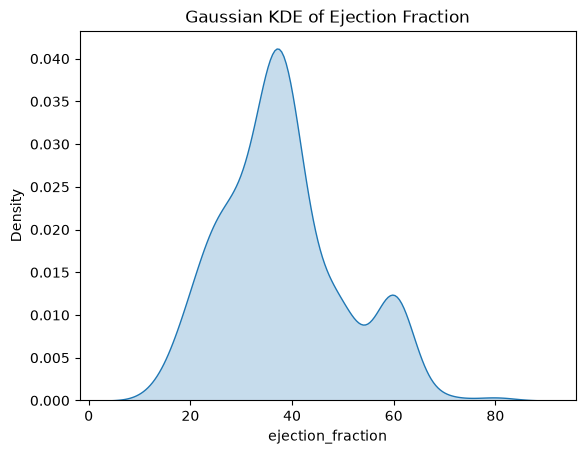

In [20]:
sns.kdeplot(data=df, x='ejection_fraction', fill=True).set(title='Gaussian KDE of Ejection Fraction')
plt.show()

### 4b. Bootstrap: resample 15 times and plot each KDE

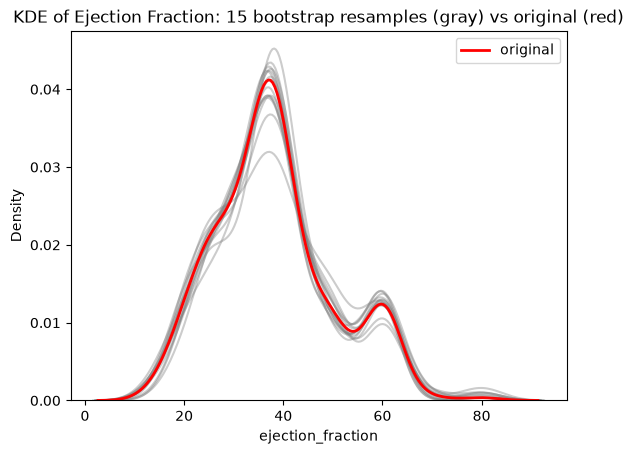

In [21]:
for i in range(15):
    df_boot = df.sample(frac=1.0, replace=True)
    sns.kdeplot(data=df_boot, x='ejection_fraction', color='gray', alpha=0.4)

# original data on top for comparison
sns.kdeplot(data=df, x='ejection_fraction', color='red', linewidth=2, label='original')
plt.title('KDE of Ejection Fraction: 15 bootstrap resamples (gray) vs original (red)')
plt.legend()
plt.show()

### 4c. Where is the original plot reliable?
*(Check this against your own plot, since the resamples are random.)*

- The original KDE is **reliable in the middle of the distribution, roughly ejection fraction ≈ 25 to 45**, where most patients are. The bootstrap curves all lie close together there, so the main peak's location and general shape are stable.
- There is **noticeable variation in the tails, especially above ~50 to 60 and below ~20**, where there are only a few patients. Also, the small bumps (for example around 60) and the exact height of the peak change from sample to sample. Those features depend on a handful of observations, so we shouldn't trust them as much.
- Ejection fraction is also recorded at a few round values (like 25, 35, 38, 40, 60), so some bumps in the KDE may just come from that rounding and not the true density.